In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [9]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X_noisy, X_clean, y_clean):
        self.X_noisy = X_noisy
        self.X_clean = X_clean
        self.y_clean = y_clean

    def __len__(self):
        return len(self.X_noisy)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X_noisy[idx], dtype=torch.float32),
            torch.tensor(self.X_clean[idx], dtype=torch.float32),
            torch.tensor(self.y_clean[idx], dtype=torch.float32)
        )


# Multi-Task Архитектура: Очистка шума (Denoising) + Seq2Seq Autoregressive Прогноз
class CNORecurrentForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. DENOISER: Очистка шума
        self.denoiser = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, padding=7),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(16),
            nn.Conv1d(16, 16, kernel_size=7, padding=3),
            nn.LeakyReLU(0.1),
            nn.Conv1d(16, 1, kernel_size=5, padding=2)
        )

   
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=4, padding=7), 
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(16),
            
            nn.Conv1d(16, 32, kernel_size=7, stride=4, padding=3), 
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(32),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=5, padding=2), 
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(64),
        )
        
        self.encoder_lstm = nn.LSTM(
            input_size=64, 
            hidden_size=128, 
            num_layers=1, 
            batch_first=True
        )

        self.decoder = nn.Sequential(
            nn.Linear(50 * 128, 512), 
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 1000)
        )

    def forward(self, x):
        x = x.unsqueeze(1)    

        denoised_past = self.denoiser(x) 
        
        c_out = self.cnn(denoised_past)   # [Batch, 64, 50]
        c_out = c_out.permute(0, 2, 1)    # [Batch, 50, 64]
        
        lstm_out, _ = self.encoder_lstm(c_out)    # [Batch, 50, 128]
        
        flat_out = lstm_out.reshape(x.size(0), -1) 

        out_future_delta = self.decoder(flat_out) # [Batch, 1000]
        
        mean_past = denoised_past.mean(dim=-1) 
        out_future = mean_past + out_future_delta
        
        return denoised_past.squeeze(1), out_future

In [10]:
train_noisy = pd.read_csv("regression/train.csv").values
train_clean = pd.read_csv("regression/etalon_for_train.csv").values

test_noisy = pd.read_csv("regression/test.csv").values
test_clean = pd.read_csv("regression/etalon_for_test.csv").values

train_X_noisy = train_noisy[:, :4000]
train_X_clean = train_clean[:, :4000] 
train_y_clean = train_clean[:, 4000:5000]

test_X_noisy = test_noisy[:, :4000]
test_X_clean = test_clean[:, :4000]
test_y_clean = test_clean[:, 4000:5000]


scaler_noisy = StandardScaler()
train_X_noisy_sc = scaler_noisy.fit_transform(train_X_noisy.reshape(-1, 1)).reshape(train_X_noisy.shape)
test_X_noisy_sc = scaler_noisy.transform(test_X_noisy.reshape(-1, 1)).reshape(test_X_noisy.shape)

scaler_clean = StandardScaler() 
scaler_clean.fit(train_clean.reshape(-1, 1))

train_X_clean_sc = scaler_clean.transform(train_X_clean.reshape(-1, 1)).reshape(train_X_clean.shape)
test_X_clean_sc = scaler_clean.transform(test_X_clean.reshape(-1, 1)).reshape(test_X_clean.shape)

train_y_clean_sc = scaler_clean.transform(train_y_clean.reshape(-1, 1)).reshape(train_y_clean.shape)
test_y_clean_sc = scaler_clean.transform(test_y_clean.reshape(-1, 1)).reshape(test_y_clean.shape)

train_dataset = TimeSeriesDataset(train_X_noisy_sc, train_X_clean_sc, train_y_clean_sc)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TimeSeriesDataset(test_X_noisy_sc, test_X_clean_sc, test_y_clean_sc)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [11]:

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNORecurrentForecaster().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4) # learning rate лучше чуть уменьшить
criterion = nn.MSELoss()

In [22]:

import torch.optim.lr_scheduler as lr_scheduler

model = CNORecurrentForecaster().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

epochs = 40 

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_n, X_c, y in train_loader:
        X_n, X_c, y = X_n.to(device), X_c.to(device), y.to(device)

        pred_past, pred_future = model(X_n)
        

        loss_denoise = criterion(pred_past, X_c)
        loss_forecast = criterion(pred_future, y)
        

        fft_target = torch.fft.rfft(y)
        fft_pred = torch.fft.rfft(pred_future)
        loss_fft = criterion(torch.abs(fft_pred), torch.abs(fft_target))
        
        loss = loss_forecast + 1.0 * loss_denoise + 0.1 * loss_fft

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}: loss={total_loss/len(train_loader):.4f}, lr={scheduler.get_last_lr()[0]:.6f}")

print("Training finished!")

Epoch 1/40: loss=39.5030, lr=0.000998
Epoch 5/40: loss=15.5533, lr=0.000962
Epoch 10/40: loss=6.3992, lr=0.000854
Epoch 15/40: loss=4.9150, lr=0.000691
Epoch 20/40: loss=4.3230, lr=0.000500
Epoch 25/40: loss=3.7347, lr=0.000309
Epoch 30/40: loss=3.4483, lr=0.000146
Epoch 35/40: loss=3.3728, lr=0.000038
Epoch 40/40: loss=3.2846, lr=0.000000
Training finished!


=== Результаты ===
MSE Очистки шума (Denoise): 0.0370
Наш Прогноз (MSE):        0.4703
Наивный Прогноз (MSE):    0.5339  <-- Last point persistence
Среднее Прошлое (MSE):    0.2699  <-- Moving average persistence


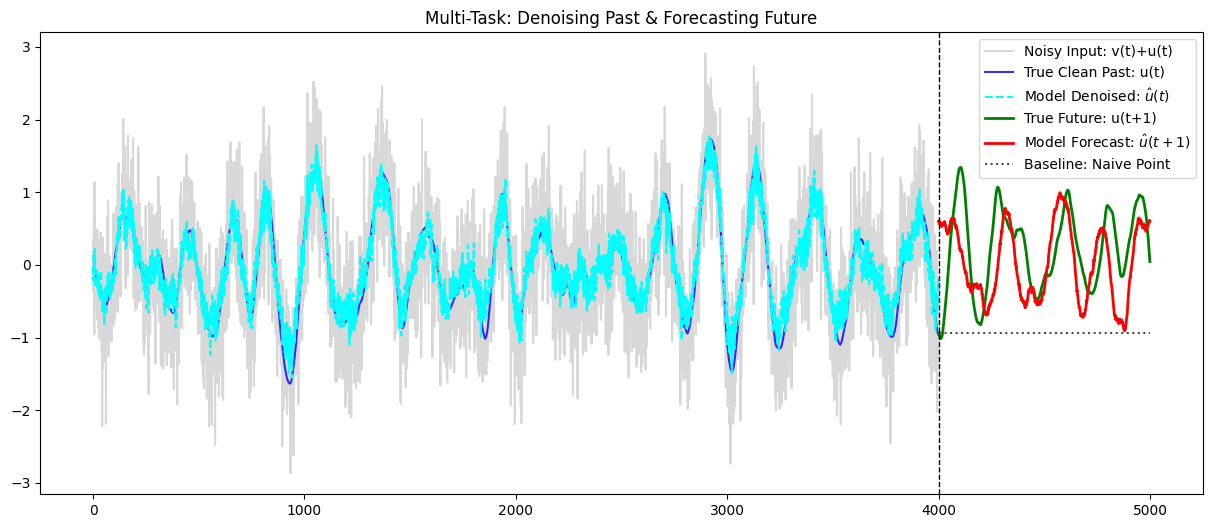

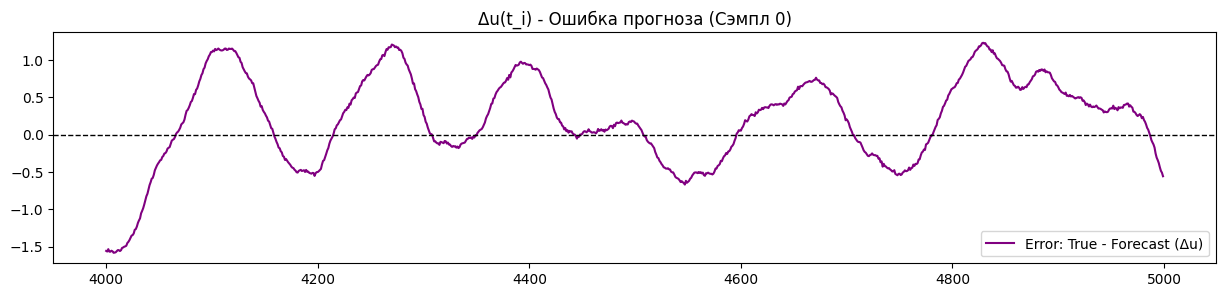

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

model.eval()
all_preds = []
all_denoised = []
all_clean = []
all_noisy = []
all_y = []

naive_point_preds = []  
mean_preds = []         

with torch.no_grad():
    for X_batch, X_clean, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        pred_past, pred_future = model(X_batch)
        
        all_preds.append(pred_future.cpu().numpy())
        all_denoised.append(pred_past.cpu().numpy())
        
        all_clean.append(X_clean.numpy())
        all_noisy.append(X_batch.cpu().numpy())
        all_y.append(y_batch.cpu().numpy())
        
        X_batch_cpu = X_batch.cpu().numpy() # [Batch, 4000]
        

        last_points = X_batch_cpu[:, -1].reshape(-1, 1) 
        naive_point_preds.append(np.repeat(last_points, 1000, axis=1))
        

        mean_past = np.mean(X_batch_cpu[:, -1000:], axis=1).reshape(-1, 1) 
        mean_preds.append(np.repeat(mean_past, 1000, axis=1))


y_pred_unscaled = np.vstack(all_preds)      # Прогноз [N, 1000]
y_denoised = np.vstack(all_denoised)        # Очищенное прошлое [N, 4000]
y_true_unscaled = np.vstack(all_y)
X_clean_unscaled = np.vstack(all_clean)
X_noisy_unscaled = np.vstack(all_noisy)

naive_point_unscaled = np.vstack(naive_point_preds)
mean_preds_unscaled = np.vstack(mean_preds)


def inverse_scale(data_2d, scaler_obj):

    data_flat = data_2d.reshape(-1, 1)
    return scaler_obj.inverse_transform(data_flat).reshape(data_2d.shape)

y_pred = inverse_scale(y_pred_unscaled, scaler_clean)
y_denoised_true = inverse_scale(y_denoised, scaler_clean)
y_true = inverse_scale(y_true_unscaled, scaler_clean)
X_c = inverse_scale(X_clean_unscaled, scaler_clean)
X_n = inverse_scale(X_noisy_unscaled, scaler_noisy)

naive_point = inverse_scale(naive_point_unscaled, scaler_clean)
mean_baseline = inverse_scale(mean_preds_unscaled, scaler_clean)

# --- МЕТРИКИ ---
mse_custom = mean_squared_error(y_true.flatten(), y_pred.flatten())
mse_naive = mean_squared_error(y_true.flatten(), naive_point.flatten())
mse_mean = mean_squared_error(y_true.flatten(), mean_baseline.flatten())
mse_denoise = mean_squared_error(X_c.flatten(), y_denoised_true.flatten())

print("=== Результаты ===")
print(f"MSE Очистки шума (Denoise): {mse_denoise:.4f}")
print(f"Наш Прогноз (MSE):        {mse_custom:.4f}")
print(f"Наивный Прогноз (MSE):    {mse_naive:.4f}  <-- Last point persistence")
print(f"Среднее Прошлое (MSE):    {mse_mean:.4f}  <-- Moving average persistence")


idx = 0 

past_time = np.arange(4000)
future_time = np.arange(4000, 5000)

plt.figure(figsize=(15, 6))

# Прошлое
plt.plot(past_time, X_n[idx], label="Noisy Input: v(t)+u(t)", alpha=0.3, color='gray')
plt.plot(past_time, X_c[idx], label="True Clean Past: u(t)", color='blue', alpha=0.8)
plt.plot(past_time, y_denoised_true[idx], label="Model Denoised: $\\hat{u}(t)$", color='cyan', linestyle="--")

# Будущее
plt.plot(future_time, y_true[idx], label="True Future: u(t+1)", color='green', linewidth=2)
plt.plot(future_time, y_pred[idx], label="Model Forecast: $\\hat{u}(t+1)$", color='red', linewidth=2)

# Бейзлайны
plt.plot(future_time, naive_point[idx], label="Baseline: Naive Point", color='black', linestyle=':', alpha=0.7)

plt.axvline(4000, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.title("Multi-Task: Denoising Past & Forecasting Future")
plt.show()


plt.figure(figsize=(15, 3))
delta_u = y_true[idx] - y_pred[idx]
plt.plot(future_time, delta_u, label="Error: True - Forecast (Δu)", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.title(f"Δu(t_i) - Ошибка прогноза (Сэмпл {idx})")
plt.show()

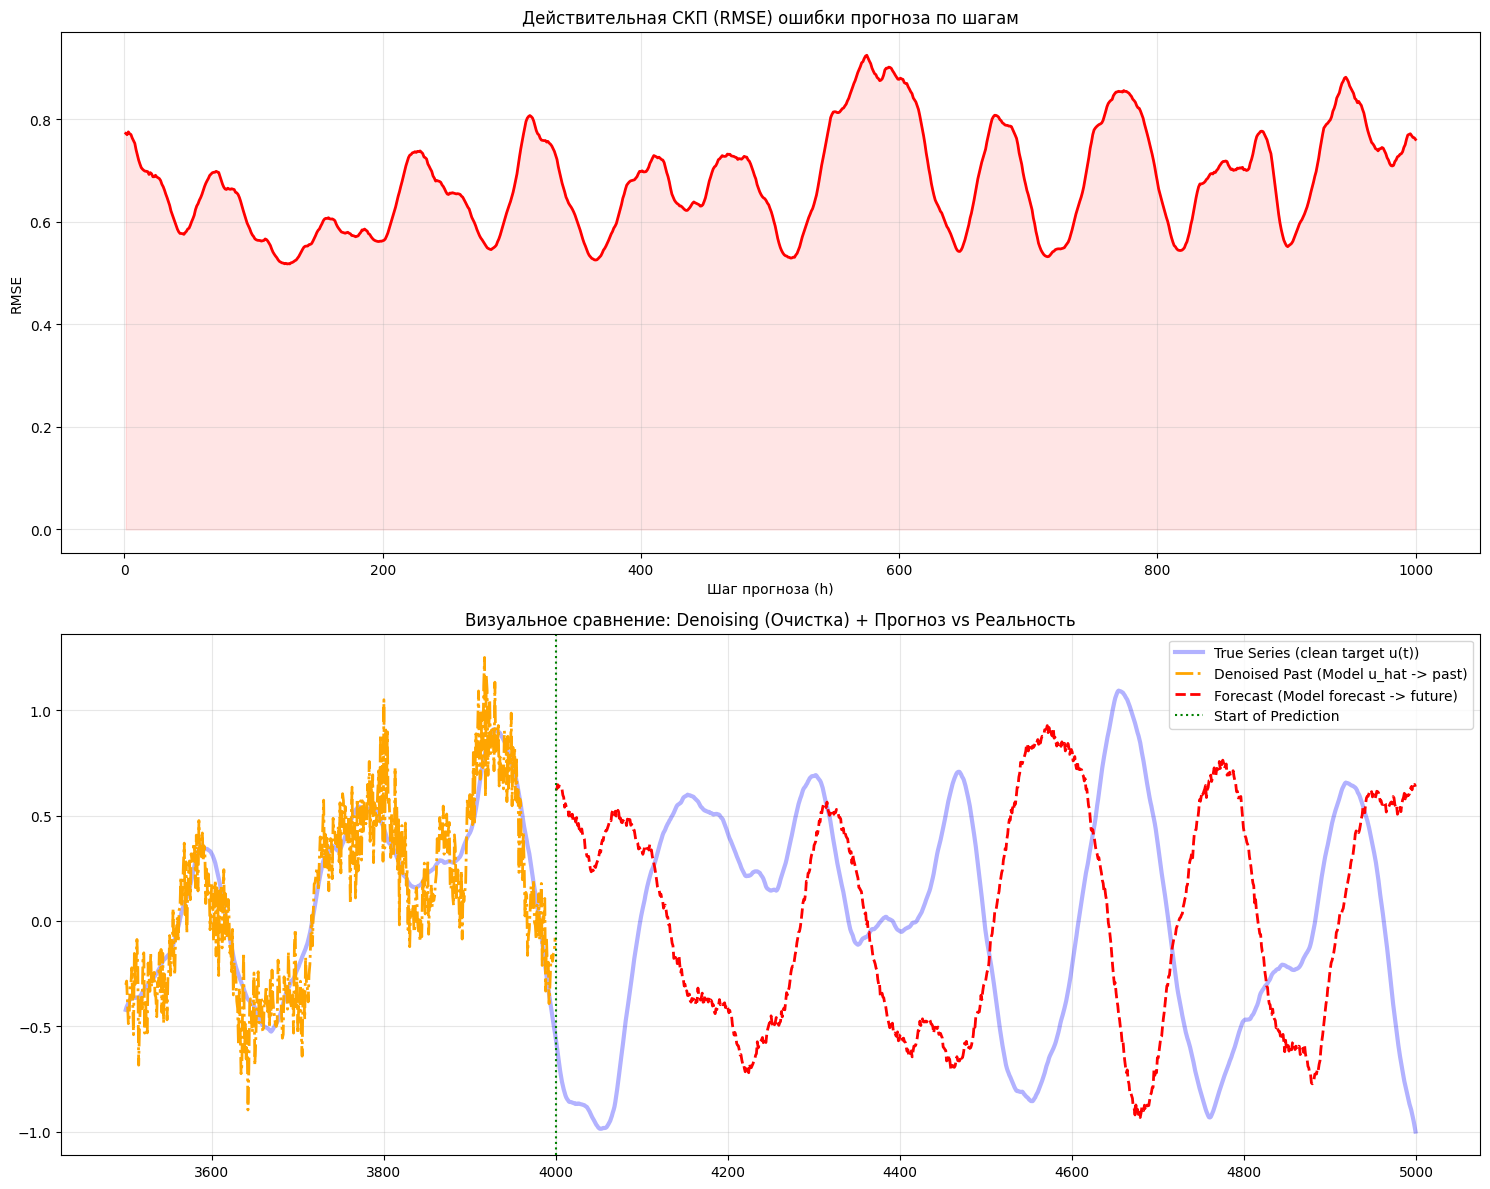

RMSE h=1: 0.7727
RMSE h=1000: 0.7608


In [24]:
import numpy as np
import matplotlib.pyplot as plt

steps_to_generate = 1000      
seed_len = 4000               
total_len = 5000

rmse_per_step = np.sqrt(np.mean((y_pred - y_true)**2, axis=0))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

ax1.plot(range(1, steps_to_generate + 1), rmse_per_step, color='red', lw=2)
ax1.fill_between(range(1, steps_to_generate + 1), 0, rmse_per_step, color='red', alpha=0.1)
ax1.set_title("Действительная СКП (RMSE) ошибки прогноза по шагам")
ax1.set_xlabel("Шаг прогноза (h)")
ax1.set_ylabel("RMSE")
ax1.grid(True, alpha=0.3)

view_count = 1500 
start_view = total_len - view_count
indices = np.arange(start_view, total_len)

idx_to_plot = -1 # Берем последний пример
last_sample_true = test_clean[idx_to_plot] # Полезный сигнал u(t) - Истина
last_preds_future = y_pred[idx_to_plot]    # Прогноз Model [4000:5000]
last_preds_past = y_denoised_true[idx_to_plot] # Очищенный сигнал Model Denoised [0:4000]

# --- Отрисовка ---
ax2.plot(indices, last_sample_true[start_view:], label="True Series (clean target u(t))", color='blue', alpha=0.3, lw=3)

# Показываем восстановленный (denoised) сигнал до 4000 точки
ax2.plot(np.arange(start_view, seed_len), last_preds_past[start_view:], label="Denoised Past (Model u_hat -> past)", color='orange', linestyle='-.', lw=2)

# Показываем сам прогноз после 4000 точки
ax2.plot(np.arange(seed_len, total_len), last_preds_future, label="Forecast (Model forecast -> future)", color='red', linestyle='--', lw=2)

ax2.axvline(x=seed_len, color='green', linestyle=':', label='Start of Prediction')

ax2.set_title("Визуальное сравнение: Denoising (Очистка) + Прогноз vs Реальность")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"RMSE h=1: {rmse_per_step[0]:.4f}")
print(f"RMSE h={steps_to_generate}: {rmse_per_step[-1]:.4f}")